In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "4"

import json
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from transformers import CLIPTokenizer, CLIPTextModel, CLIPTextModelWithProjection
from tqdm import tqdm
from safetensors.torch import load_file

/local2/kunkim/dti/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tokenizer = CLIPTokenizer.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0", subfolder="tokenizer"
)
text_encoder = CLIPTextModel.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0", subfolder="text_encoder"
)
text_encoder.eval().cuda().requires_grad_(False)
embeddings = text_encoder.text_model.embeddings
token_embeddings = text_encoder.get_input_embeddings().weight.clone().detach()

tokenizer = CLIPTokenizer.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0", subfolder="tokenizer_2"
)
text_encoder_2 = CLIPTextModelWithProjection.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0", subfolder="text_encoder_2"
)
text_encoder_2.eval().cuda().requires_grad_(False)
embeddings_2 = text_encoder_2.text_model.embeddings
token_embeddings_2 = text_encoder_2.get_input_embeddings().weight.clone().detach()

In [3]:
class PromptDataset(Dataset):
    def __init__(self, tokenizer, prompt_files):
        self.tokenizer = tokenizer
        self.prompts = []
        for pf in prompt_files:
            with open(pf, "r") as f:
                for line in f:
                    data = json.loads(line)
                    self.prompts.append(self._clean_prompt(data["input"]))
                    self.prompts.append(self._clean_prompt(data["output"]))

    def _clean_prompt(self, prompt):
        if prompt.startswith("'") and prompt.endswith("'"):
            prompt = prompt[1:-1]
        return prompt

    def __len__(self):
        return len(self.prompts)

    def __getitem__(self, idx):
        prompt = self.prompts[idx]
        encoding = self.tokenizer(
            prompt,
            padding="max_length",
            max_length=77,
            truncation=True,
            return_tensors="pt",
        )
        input_ids = encoding["input_ids"].squeeze(0)
        # label is the position index of the each token
        labels = torch.arange(input_ids.size(0))
        return input_ids, labels

In [8]:
class PositionClassifier(nn.Module):
    def __init__(
        self,
        dim,
        embeddings,
        layernorm0,
        num_classes=77,
    ):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, num_classes)
        self.embeddings = embeddings
        self.layernorm0 = layernorm0
        # Make sure to freeze embeddings/layernorm0
        self.embeddings.requires_grad_(False)
        self.layernorm0.requires_grad_(False)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

    def posemb_norm(
        self,
        input_ids,
        position_ids=None,
        target_scale: float | None = None,
        tok_embeds: torch.Tensor | None = None,
    ):
        if tok_embeds is None:
            tok_embeds = self.embeddings.token_embedding(input_ids)
        if position_ids is None:
            position_ids = self.embeddings.position_ids[:, : input_ids.size(-1)]
        pos_embeds = self.embeddings.position_embedding(position_ids)
        if target_scale is not None:
            tok_embeds = (
                tok_embeds / tok_embeds.norm(dim=-1, keepdim=True) * target_scale
            )
        hs = tok_embeds + pos_embeds
        normalized_hs = self.layernorm0(hs)
        return normalized_hs


# Batch test
def test_with_scale(model, scale: float, batch_size: int = 100):
    total_sample = 0
    total_correct = 0
    vocab_size = model.embeddings.token_embedding.num_embeddings
    for i in range(10):
        rand_token_ids = torch.randint(0, vocab_size, (batch_size, 1)).cuda()
        hs = model.posemb_norm(rand_token_ids, target_scale=scale)
        outputs = model(hs.view(-1, hs.size(-1)))
        predicted_positions = torch.argmax(outputs, dim=-1)
        target = (
            torch.arange(rand_token_ids.size(1))
            .unsqueeze(0)
            .repeat(batch_size, 1)
            .cuda()
            .view(-1)
        )
        # print("Predicted positions:", predicted_positions.cpu().tolist())
        num_correct = (predicted_positions == target).sum().item()
        total_correct += num_correct
        total_sample += target.size(0)
    accuracy = total_correct / total_sample
    return accuracy

In [5]:
model = PositionClassifier(
    768,
    embeddings=embeddings,
    layernorm0=text_encoder.text_model.encoder.layers[0].layer_norm1,
).cuda()
params_to_train = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(
    params=model.parameters(),
    lr=1e-4,
    weight_decay=1e-2,
)

dataset = PromptDataset(
    tokenizer,
    [
        "../tmp/gpt-generated-prompts.jsonl",
        "../tmp/human-written-prompts.jsonl",
    ],
)
for prompt in dataset.prompts[:10]:
    print(prompt)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
pbar = tqdm(dataloader, total=len(dataloader))
i = 0
for batch in pbar:
    input_ids, labels = batch
    input_ids = input_ids.cuda()
    labels = labels.cuda()

    with torch.no_grad():
        hs = model.posemb_norm(input_ids)

    # Flatten hs and labels.
    batch_size, seq_len, dim = hs.size()
    hs = hs.view(-1, dim)
    labels = labels.view(-1)
    # Shuffle the data
    perm = torch.randperm(hs.size(0))
    hs = hs[perm]
    labels = labels[perm]

    outputs = model(hs)
    loss = F.cross_entropy(outputs.view(-1, outputs.size(-1)), labels.view(-1))
    loss.backward()
    optimizer.step()
    optimizer.zero_grad(set_to_none=True)

    pbar.set_description(f"Loss: {loss.item():.4f}")
    i += 1

    if i >= 1000:
        break

"Dreama Tolle Perry » Artist and Writer » ""Tuscany Outside My Door"""
"Dreama Tolle Perry » Artist and Writer » ""Tuscany in Alaska Outside My Door"""
Medieval village of Montefioralle in Tuscany, Italy
Medieval village of Montefioralle in Nintendogs game
"""ANATOLE KRASNYANSKY """"MEMORIES OF PRAGUE"""" Hand Signed Limited Edition Lithograph"""
"""ANATOLE KRASNYANSKY """"MEMORIES OF PRAGUE"""" Watercolor Painting"""
Cormorant, Li-River, Xingping, China, fishing village, bird, National Geographic Traveler Photo Contest (horizontal)
Vulture, Li-River, Xingping, China, fishing village, bird, National Geographic Traveler Photo Contest (horizontal)
Architect George Suyama
Architect George Suyama in a comic book


Loss: 0.0052:   4%|▎         | 999/28303 [00:15<06:57, 65.33it/s]


{'normal': 1.0, '0.5': 1.0, '1': 1.0, '2': 0.882, '4': 0.309, '8': 0.065, '16': 0.03}


Text(0, 0.5, 'Accuracy')

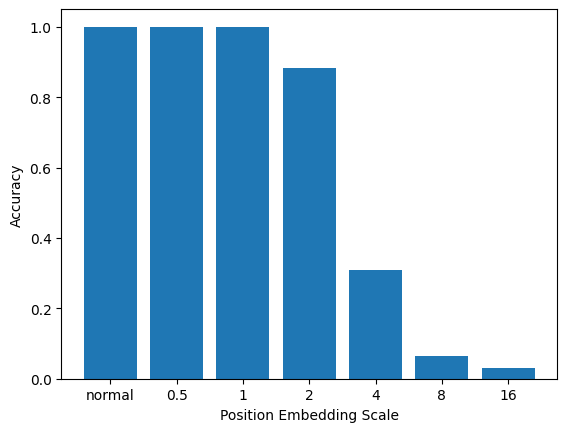

In [9]:
results = {}
for s in [None, 0.5, 1, 2, 4, 8, 16]:
    acc = test_with_scale(model, s)
    if s is None:
        results["normal"] = acc
    else:
        results[str(s)] = acc
print(results)
# plt.plot(list(results.keys()), list(results.values()))
plt.bar(list(results.keys()), list(results.values()))
plt.xlabel("Position Embedding Scale")
plt.ylabel("Accuracy")

In [18]:
# Test with learned embeddings.

# Step 1: load all embeddings.
def gather_learned_embeddings(
    target_dir: str, embedding_name: str = "learned_embeds.safetensors"
):
    instances = Path(target_dir).iterdir()
    learned_embeddings = []
    for instance in instances:
        if not instance.is_dir():
            continue
        learned_embedding = load_file(instance / embedding_name)
        for k, v in learned_embedding.items():
            learned_embeddings.append(v)
    learned_embeddings = torch.cat(learned_embeddings, dim=0).cuda()
    print("Learned embeddings shape:", learned_embeddings.shape)
    return learned_embeddings


def test_with_learned_embeddings(model, learned_embeddings):
    # Step 2: test with learned embeddings.
    total_sample = 0
    total_correct = 0
    batch_size = 100
    for i in range(10):
        rand_token_ids = torch.randint(
            0, learned_embeddings.size(0), (batch_size, 1)
        ).cuda()
        embeds = learned_embeddings[rand_token_ids]
        position_ids = model.embeddings.position_ids[:, : embeds.size(1)]
        pos_embeds = model.embeddings.position_embedding(position_ids)
        hs = embeds + pos_embeds
        normalized_hs = model.layernorm0(hs)
        outputs = model(normalized_hs.view(-1, normalized_hs.size(-1)))
        predicted_positions = torch.argmax(outputs, dim=-1)
        target = (
            torch.arange(rand_token_ids.size(1))
            .unsqueeze(0)
            .repeat(batch_size, 1)
            .cuda()
            .view(-1)
        )
        num_correct = (predicted_positions == target).sum().item()
        total_correct += num_correct
        total_sample += target.size(0)
    accuracy = total_correct / total_sample
    print(f"Accuracy with learned embeddings: {accuracy:.4f}")
    return accuracy


target_dir = "../output/ti-sdxl-1029-test"
# target_dir = "../output/dti-sdxl-1117-debug-v2"
# target_dir = "../output/dti-sdxl-1102-no_pad-b0.0"
# target_dir = "../output/dti-sdxl-1102-no_pad-b0.95"

learned_embeddings = gather_learned_embeddings(target_dir)
accuracy = test_with_learned_embeddings(model, learned_embeddings)

Learned embeddings shape: torch.Size([33, 768])
Accuracy with learned embeddings: 0.0000


# Test with Second Text Encoder

In [11]:
model_2 = PositionClassifier(
    1280,
    embeddings=embeddings_2,
    layernorm0=text_encoder_2.text_model.encoder.layers[0].layer_norm1,
).cuda()
params_to_train_2 = [p for p in model_2.parameters() if p.requires_grad]
optimizer_2 = torch.optim.AdamW(
    params=params_to_train_2,
    lr=1e-4,
    weight_decay=1e-2,
)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
pbar = tqdm(dataloader, total=len(dataloader))
i = 0
for batch in pbar:
    input_ids, labels = batch
    input_ids = input_ids.cuda()
    labels = labels.cuda()

    with torch.no_grad():
        hs = model_2.posemb_norm(input_ids)

    # Flatten hs and labels.
    batch_size, seq_len, dim = hs.size()
    hs = hs.view(-1, dim)
    labels = labels.view(-1)
    # Shuffle the data
    perm = torch.randperm(hs.size(0))
    hs = hs[perm]
    labels = labels[perm]

    outputs = model_2(hs)
    loss = F.cross_entropy(outputs.view(-1, outputs.size(-1)), labels.view(-1))
    loss.backward()
    optimizer_2.step()
    optimizer_2.zero_grad(set_to_none=True)

    pbar.set_description(f"Loss: {loss.item():.4f}")
    i += 1

    if i >= 1000:
        break

Loss: 0.0028:   4%|▎         | 999/28303 [00:14<06:43, 67.73it/s]


{'normal': 1.0, '0.5': 1.0, '1': 1.0, '2': 0.846, '4': 0.076, '8': 0.008, '16': 0.005}


Text(0, 0.5, 'Accuracy')

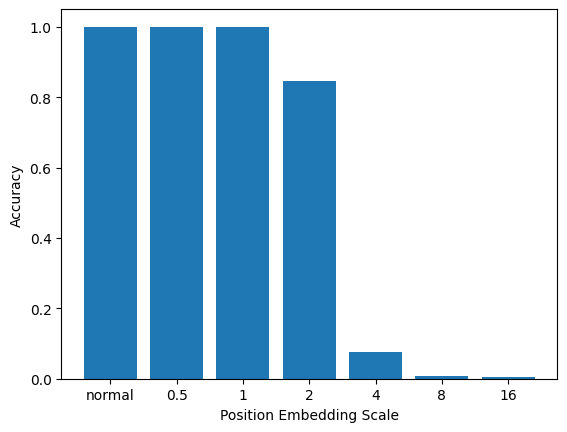

In [12]:
results = {}
for s in [None, 0.5, 1, 2, 4, 8, 16]:
    acc = test_with_scale(model_2, s)
    if s is None:
        results["normal"] = acc
    else:
        results[str(s)] = acc
print(results)
# plt.plot(list(results.keys()), list(results.values()))
plt.bar(list(results.keys()), list(results.values()))
plt.xlabel("Position Embedding Scale")
plt.ylabel("Accuracy")

In [21]:
target_dir = "../output/ti-sdxl-1029-test"
# target_dir = "../output/dti-sdxl-1117-debug-v2"
# target_dir = "../output/dti-sdxl-1102-no_pad-b0.0"
# target_dir = "../output/dti-sdxl-1102-no_pad-b0.95"

learned_embeddings_2 = gather_learned_embeddings(
    target_dir, embedding_name="learned_embeds_2.safetensors"
)
accuracy = test_with_learned_embeddings(model_2, learned_embeddings_2)

Learned embeddings shape: torch.Size([33, 1280])
Accuracy with learned embeddings: 0.0000
